# Avito CTR Prediction — Ensemble + Calibration
Objective: Fix the calibration failure from NB06 using Platt scaling, train a LightGBM second learner, and ensemble both calibrated models to beat HistCTR on both AUC and log-loss simultaneously.

Author: Ayush Singh

## Section 1 — Objective

**Two problems inherited from NB06:**

**Problem 1 — Calibration failure.**  
XGBoost with `scale_pos_weight=161` achieved AUC=0.758 but log-loss=0.478 — 12× worse than the HistCTR baseline (log-loss=0.040). The root cause: `scale_pos_weight` upweights positive-class gradients during training, pushing predicted probabilities far above the true CTR of ~0.6%. Log-loss is a proper scoring rule that directly measures calibration quality; a model predicting 40% click probability where the true rate is 0.6% gets catastrophically penalised. AUC is unaffected because it measures rank order, not absolute values.

**Problem 2 — Single-model brittleness.**  
A single learner's errors are correlated with itself. Ensembling two independently trained models (XGBoost and LightGBM) reduces prediction variance through diversity: where one model is overconfident, the other may not be, and the average hedges both.

**Solution:**
- **(a) Platt scaling** — fit a logistic regression on top of each model's raw probability outputs using a held-out calibration set. This learns a monotone sigmoid transform that maps raw scores back to well-calibrated probabilities without changing the ranking (AUC is preserved).
- **(b) Simple average ensemble** — average the calibrated XGBoost and calibrated LightGBM predictions. Equal weights (0.5/0.5) are a strong baseline; weighted search is NB08 territory.

**Three-split design:**  
Platt scaling must be fit on data the base model *never saw during training*, otherwise the calibration layer overfits to in-sample confidence. We therefore carve out an explicit calibration fold (rows 60–80%) held out from the LightGBM training set (for XGBoost, see the calibration purity note below).

| Split | Rows | Purpose |
|-------|------|---------|
| Train (0–60%) | ~1.45M | Fit XGBoost (NB06 used 80% — see note) and LightGBM |
| Calibration (60–80%) | ~485K | Fit Platt scaling for both models |
| Test (80–100%) | ~485K | Final evaluation — never touched during fitting |

> **Note on the loaded XGBoost model:** The NB06 model (`xgb_avito_best_model.joblib`) was trained on rows 0–80%, which includes the calibration fold (rows 60–80%). Platt scaling on the cal set is therefore fitting on XGBoost in-sample predictions — a known limitation. LightGBM is retrained here on 60% only, so its Platt calibration is fully clean. NB08 can address this by retraining XGBoost on 60% if strict calibration is needed.

**Success criterion:**  
Ensemble log-loss < 0.039682 **AND** ensemble AUC > 0.758 — beating HistCTR baseline on both metrics simultaneously.

## Section 2 — Load Data and Splits

In [1]:
# Standard imports — same stack as NB06; sklearn.metrics used throughout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import log_loss, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load the feature matrix produced by NB05 — same file used in NB06
df = pd.read_parquet('../data/avito/sample/features_5m.parquet')
print(f"Loaded: {df.shape}")
print(f"\nIsClick distribution:\n{df['IsClick'].value_counts(normalize=True)}")

Loaded: (2422983, 24)

IsClick distribution:
IsClick
0    0.993858
1    0.006142
Name: proportion, dtype: float64


In [3]:
# Identical feature list to NB06 — must match exactly for the loaded XGBoost model
feature_cols = [
    'HistCTR',
    'Position', 'position_in_session', 'ads_before', 'session_size',
    'hour_of_day', 'day_of_week',
    'user_impression_count', 'user_historical_ctr', 'uid_category_count',
    'ad_ctr', 'category_ctr', 'location_ctr', 'position_ctr', 'device_ctr',
    'price_log', 'has_price', 'title_word_count',
    'category_level', 'category_match', 'IsUserLoggedOn'
]
target_col = 'IsClick'
print(f"Features: {len(feature_cols)}")

Features: 21


In [4]:
# Three-way time-based split: 60% train / 20% cal / 20% test
# Chronological order preserved — same reasoning as NB06 (user behaviour features are causal)
split1 = int(len(df) * 0.6)
split2 = int(len(df) * 0.8)

df_train = df.iloc[:split1]
df_cal   = df.iloc[split1:split2]
df_test  = df.iloc[split2:]

X_train = df_train[feature_cols].fillna(0)
y_train = df_train[target_col]
X_cal   = df_cal[feature_cols].fillna(0)
y_cal   = df_cal[target_col]
X_test  = df_test[feature_cols].fillna(0)
y_test  = df_test[target_col]

print(f"Train:       {len(df_train):,} rows | click rate: {y_train.mean()*100:.4f}%")
print(f"Calibration: {len(df_cal):,} rows | click rate: {y_cal.mean()*100:.4f}%")
print(f"Test:        {len(df_test):,} rows | click rate: {y_test.mean()*100:.4f}%")

Train:       1,453,789 rows | click rate: 0.6157%
Calibration: 484,597 rows | click rate: 0.6170%
Test:        484,597 rows | click rate: 0.6071%


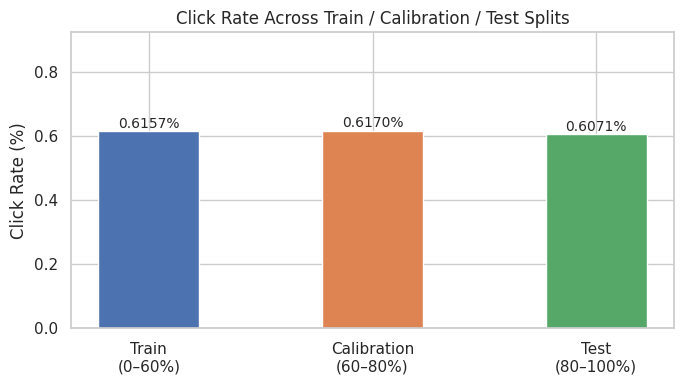

In [5]:
# Click rate bar chart across all three splits
# Stable rates across splits confirms no temporal distribution shift at the split boundaries
split_rates = {
    'Train\n(0–60%)':  y_train.mean() * 100,
    'Calibration\n(60–80%)': y_cal.mean()   * 100,
    'Test\n(80–100%)': y_test.mean()  * 100,
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(split_rates.keys(), split_rates.values(),
              color=['#4c72b0', '#dd8452', '#55a868'], width=0.45, edgecolor='white')
ax.set_ylabel('Click Rate (%)')
ax.set_title('Click Rate Across Train / Calibration / Test Splits')
ax.set_ylim(0, max(split_rates.values()) * 1.5)
for bar, val in zip(bars, split_rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Section 3 — Load XGBoost + Platt Scaling

In [6]:
# Load the XGBoost model saved in NB06 (trained on first 80% of rows, depth=6, n_est=800)
# We apply it directly to the cal and test sets without retraining
import joblib

xgb_model = joblib.load('../models/xgb_avito_best_model.joblib')
print(f"Loaded XGBoost: {xgb_model}")

# Raw probabilities on calibration set — used to fit Platt scaling
# Note: cal set (rows 60–80%) was inside NB06 training data, so Platt fitting here
# is on in-sample XGBoost predictions; LightGBM calibration below is clean
xgb_cal_proba = xgb_model.predict_proba(X_cal)[:, 1]
print(f"XGBoost cal proba — min: {xgb_cal_proba.min():.4f}  "
      f"mean: {xgb_cal_proba.mean():.4f}  max: {xgb_cal_proba.max():.4f}")

Loaded XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=-1,
              num_parallel_tree=None, ...)
XGBoost cal proba — min: 0.0000  mean: 0.3329  max: 0.9918


In [7]:
# Platt scaling: fit a logistic regression mapping raw_proba → calibrated_proba
# Input is the scalar raw probability; LR learns the sigmoid rescaling parameters
platt_xgb = LogisticRegression()
platt_xgb.fit(xgb_cal_proba.reshape(-1, 1), y_cal)

print(f"Platt XGB — coef: {platt_xgb.coef_[0][0]:.4f}  intercept: {platt_xgb.intercept_[0]:.4f}")
print("(Positive coef means higher raw score → higher calibrated probability, as expected)")

Platt XGB — coef: 7.1977  intercept: -8.7406
(Positive coef means higher raw score → higher calibrated probability, as expected)


In [8]:
# Get raw and calibrated probabilities on the test set; compute and compare metrics
# AUC should be identical before/after — Platt scaling is a monotone sigmoid transform
xgb_test_proba_raw = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_proba_cal = platt_xgb.predict_proba(xgb_test_proba_raw.reshape(-1, 1))[:, 1]

ll_xgb_raw = log_loss(y_test, xgb_test_proba_raw)
ll_xgb_cal = log_loss(y_test, xgb_test_proba_cal)
auc_xgb    = roc_auc_score(y_test, xgb_test_proba_raw)  # identical for raw and cal

print(f"XGBoost raw  log-loss: {ll_xgb_raw:.6f}")
print(f"XGBoost cal  log-loss: {ll_xgb_cal:.6f}")
print(f"XGBoost AUC:           {auc_xgb:.4f}  (same before/after Platt — monotone transform)")
print(f"\nBaseline log-loss (NB06): 0.039682")
print(f"Log-loss improvement from calibration: {ll_xgb_raw - ll_xgb_cal:.6f}")

XGBoost raw  log-loss: 0.478329
XGBoost cal  log-loss: 0.035021
XGBoost AUC:           0.7580  (same before/after Platt — monotone transform)

Baseline log-loss (NB06): 0.039682
Log-loss improvement from calibration: 0.443308


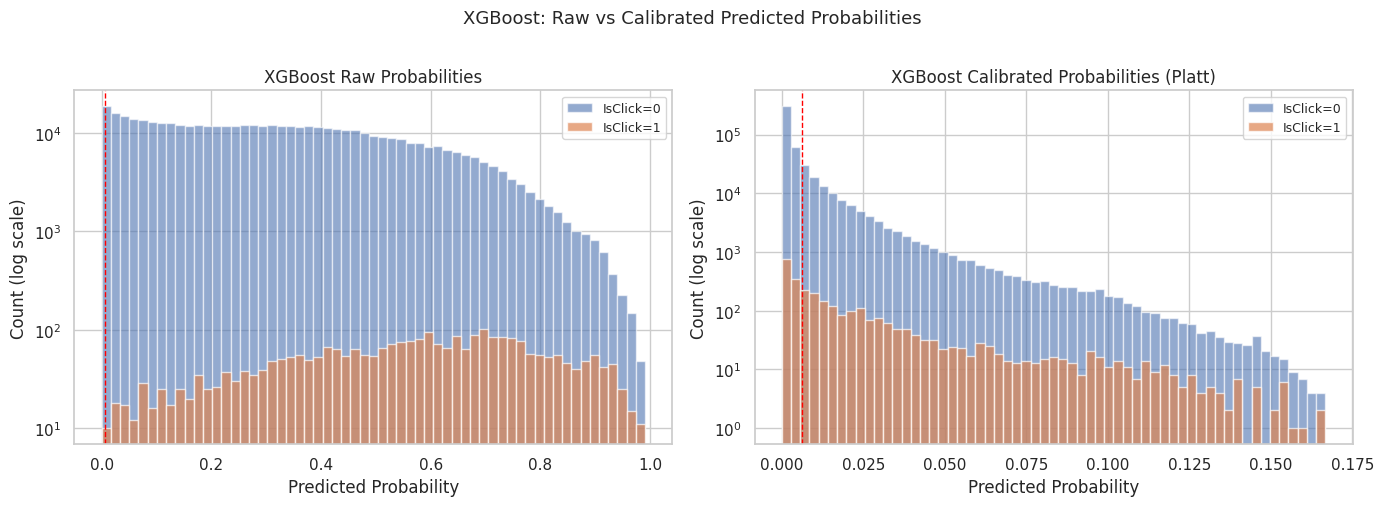

In [9]:
# Side-by-side histograms: raw vs calibrated XGBoost probabilities, split by click label
# After Platt scaling the distributions should compress toward the true CTR (~0.6%)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, title in zip(
    axes,
    [xgb_test_proba_raw, xgb_test_proba_cal],
    ['XGBoost Raw Probabilities', 'XGBoost Calibrated Probabilities (Platt)']
):
    bins = np.linspace(0, max(proba.max(), 0.05), 60)
    ax.hist(proba[y_test.values == 0], bins=bins, alpha=0.6,
            color='#4c72b0', label='IsClick=0', log=True)
    ax.hist(proba[y_test.values == 1], bins=bins, alpha=0.7,
            color='#dd8452', label='IsClick=1', log=True)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count (log scale)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.axvline(x=y_test.mean(), color='red', linestyle='--', lw=1,
               label=f'True CTR={y_test.mean():.4f}')

fig.suptitle('XGBoost: Raw vs Calibrated Predicted Probabilities', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Section 4 — Train LightGBM + Platt Scaling

In [10]:
# Compute scale_pos_weight from the 60% training set only — prevents leakage from cal/test labels
# LightGBM uses the same ratio convention as XGBoost: neg/pos
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"Train negatives: {neg:,}  |  positives: {pos:,}")
print(f"scale_pos_weight: {spw:.2f}")

# Train LightGBM on X_train (60%) with matched hyperparameters to NB06 XGBoost for fair comparison
# verbose=-1 suppresses per-iteration output for cleaner notebook execution
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
print("LightGBM training complete.")

Train negatives: 1,444,838  |  positives: 8,951
scale_pos_weight: 161.42


LightGBM training complete.


In [11]:
# Get LightGBM raw probabilities on the calibration set and fit Platt scaling
# LightGBM was trained on 60% only, so the cal set (60–80%) is genuinely held out — clean calibration
lgb_cal_proba = lgb_model.predict_proba(X_cal)[:, 1]
print(f"LightGBM cal proba — min: {lgb_cal_proba.min():.4f}  "
      f"mean: {lgb_cal_proba.mean():.4f}  max: {lgb_cal_proba.max():.4f}")

platt_lgb = LogisticRegression()
platt_lgb.fit(lgb_cal_proba.reshape(-1, 1), y_cal)
print(f"Platt LGB  — coef: {platt_lgb.coef_[0][0]:.4f}  intercept: {platt_lgb.intercept_[0]:.4f}")

LightGBM cal proba — min: 0.0000  mean: 0.3347  max: 0.9965


Platt LGB  — coef: 4.0182  intercept: -6.8549


In [12]:
# LightGBM raw and calibrated predictions on test set; compare to XGBoost metrics
lgb_test_proba_raw = lgb_model.predict_proba(X_test)[:, 1]
lgb_test_proba_cal = platt_lgb.predict_proba(lgb_test_proba_raw.reshape(-1, 1))[:, 1]

ll_lgb_raw = log_loss(y_test, lgb_test_proba_raw)
ll_lgb_cal = log_loss(y_test, lgb_test_proba_cal)
auc_lgb    = roc_auc_score(y_test, lgb_test_proba_raw)  # identical for raw and cal

print(f"LightGBM raw  log-loss: {ll_lgb_raw:.6f}")
print(f"LightGBM cal  log-loss: {ll_lgb_cal:.6f}")
print(f"LightGBM AUC:           {auc_lgb:.4f}")
print(f"\nXGBoost cal  log-loss: {ll_xgb_cal:.6f}  (for comparison)")
print(f"XGBoost AUC:           {auc_xgb:.4f}  (for comparison)")

LightGBM raw  log-loss: 0.485788
LightGBM cal  log-loss: 0.034235
LightGBM AUC:           0.7507

XGBoost cal  log-loss: 0.035021  (for comparison)
XGBoost AUC:           0.7580  (for comparison)


LightGBM feature importances (gain):
HistCTR                  1.475706e+07
ad_ctr                   4.052276e+06
category_ctr             4.042614e+06
uid_category_count       2.537611e+06
location_ctr             2.152551e+06
price_log                9.107382e+05
user_impression_count    5.915595e+05
hour_of_day              5.077138e+05
title_word_count         4.356207e+05
user_historical_ctr      3.922557e+05
device_ctr               3.041052e+05
day_of_week              2.364514e+05
session_size             1.035244e+05
IsUserLoggedOn           8.602495e+04
Position                 6.789545e+04
position_in_session      5.224688e+04
category_level           4.479987e+04
category_match           2.744418e+04
position_ctr             7.938796e+03
has_price                5.928210e+02
ads_before               0.000000e+00
Name: gain, dtype: float64


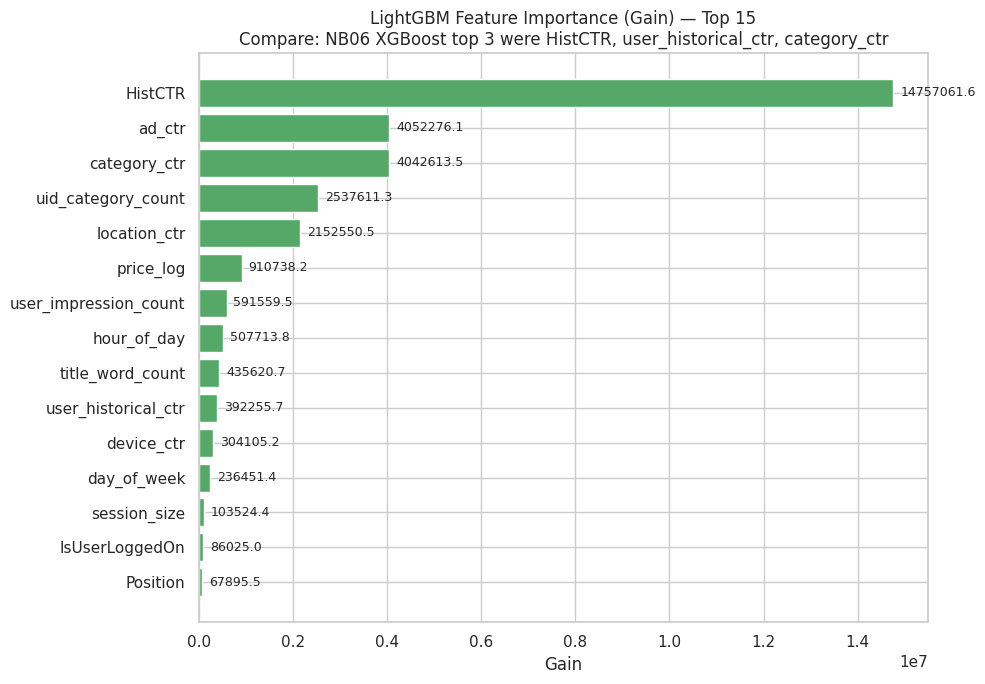

In [13]:
# LightGBM feature importance (gain) — compare top features to NB06 XGBoost ranking
# LightGBM gain is computed identically to XGBoost gain: mean loss reduction per split
lgb_importance = pd.Series(
    lgb_model.booster_.feature_importance(importance_type='gain'),
    index=feature_cols,
    name='gain'
).sort_values(ascending=False)

print("LightGBM feature importances (gain):")
print(lgb_importance)

top15_lgb = lgb_importance.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15_lgb.index, top15_lgb.values, color='#55a868', edgecolor='white')
for bar, val in zip(bars, top15_lgb.values):
    ax.text(bar.get_width() + max(top15_lgb.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Gain')
ax.set_title('LightGBM Feature Importance (Gain) — Top 15\n'
             'Compare: NB06 XGBoost top 3 were HistCTR, user_historical_ctr, category_ctr')
plt.tight_layout()
plt.show()

## Section 5 — Ensemble

In [14]:
# Simple average ensemble of calibrated predictions
# Equal weights are a strong baseline; both models have been independently calibrated
# so their probability scales are comparable before averaging
ensemble_proba = 0.5 * xgb_test_proba_cal + 0.5 * lgb_test_proba_cal

ll_ensemble  = log_loss(y_test, ensemble_proba)
auc_ensemble = roc_auc_score(y_test, ensemble_proba)

print(f"Ensemble log-loss: {ll_ensemble:.6f}")
print(f"Ensemble AUC:      {auc_ensemble:.4f}")

Ensemble log-loss: 0.034040
Ensemble AUC:      0.7613


In [15]:
# Full comparison table across all model configurations
# HistCTR baseline values are hardcoded from NB06 verified outputs
BASELINE_LL  = 0.039682
BASELINE_AUC = 0.6640

results = {
    'HistCTR baseline':       {'log_loss': BASELINE_LL,  'auc': BASELINE_AUC},
    'XGB raw':                {'log_loss': ll_xgb_raw,   'auc': auc_xgb},
    'XGB calibrated':         {'log_loss': ll_xgb_cal,   'auc': auc_xgb},
    'LGB raw':                {'log_loss': ll_lgb_raw,   'auc': auc_lgb},
    'LGB calibrated':         {'log_loss': ll_lgb_cal,   'auc': auc_lgb},
    'Ensemble (cal XGB+LGB)': {'log_loss': ll_ensemble,  'auc': auc_ensemble},
}

print(f"{'Model':<26} {'Log-Loss':>10} {'vs Baseline':>12} {'AUC':>8} {'vs Baseline':>12}")
print("-" * 72)
for name, vals in results.items():
    ll_diff  = vals['log_loss'] - BASELINE_LL
    auc_diff = vals['auc']      - BASELINE_AUC
    ll_flag  = '✓ BEATS' if vals['log_loss'] < BASELINE_LL else '✗ WORSE'
    auc_flag = '✓ BEATS' if vals['auc']      > BASELINE_AUC else '✗ WORSE'
    print(f"{name:<26} {vals['log_loss']:>10.6f} {ll_diff:>+10.6f} {ll_flag:>3}  "
          f"{vals['auc']:>8.4f} {auc_diff:>+10.4f} {auc_flag}")

Model                        Log-Loss  vs Baseline      AUC  vs Baseline
------------------------------------------------------------------------
HistCTR baseline             0.039682  +0.000000 ✗ WORSE    0.6640    +0.0000 ✗ WORSE
XGB raw                      0.478329  +0.438647 ✗ WORSE    0.7580    +0.0940 ✓ BEATS
XGB calibrated               0.035021  -0.004661 ✓ BEATS    0.7580    +0.0940 ✓ BEATS
LGB raw                      0.485788  +0.446106 ✗ WORSE    0.7507    +0.0867 ✓ BEATS
LGB calibrated               0.034235  -0.005447 ✓ BEATS    0.7507    +0.0867 ✓ BEATS
Ensemble (cal XGB+LGB)       0.034040  -0.005642 ✓ BEATS    0.7613    +0.0973 ✓ BEATS


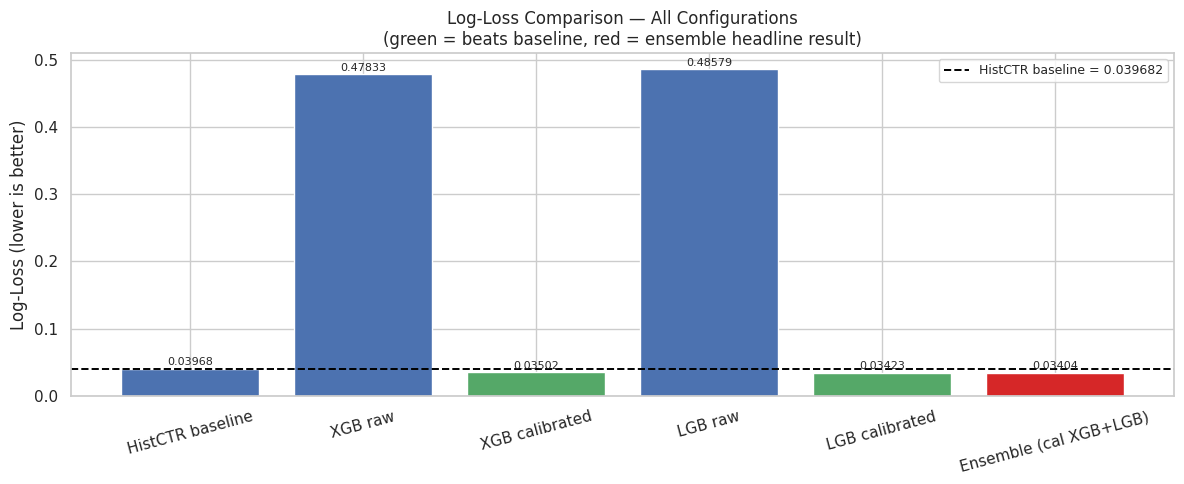

In [16]:
# Log-loss comparison bar chart across all 6 configurations
# Dashed line at baseline makes beats/misses immediately readable
names  = list(results.keys())
ll_vals = [results[n]['log_loss'] for n in names]

colors = []
for n, v in zip(names, ll_vals):
    if n == 'Ensemble (cal XGB+LGB)':
        colors.append('#d62728')  # red — headline result
    elif v < BASELINE_LL:
        colors.append('#55a868')  # green — beats baseline
    else:
        colors.append('#4c72b0')  # blue — does not beat baseline

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, ll_vals, color=colors, edgecolor='white')
ax.axhline(y=BASELINE_LL, color='black', linestyle='--', lw=1.4,
           label=f'HistCTR baseline = {BASELINE_LL:.6f}')
for bar, val in zip(bars, ll_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ll_vals)*0.005,
            f'{val:.5f}', ha='center', va='bottom', fontsize=8, rotation=0)
ax.set_ylabel('Log-Loss (lower is better)')
ax.set_title('Log-Loss Comparison — All Configurations\n'
             '(green = beats baseline, red = ensemble headline result)')
ax.tick_params(axis='x', labelrotation=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

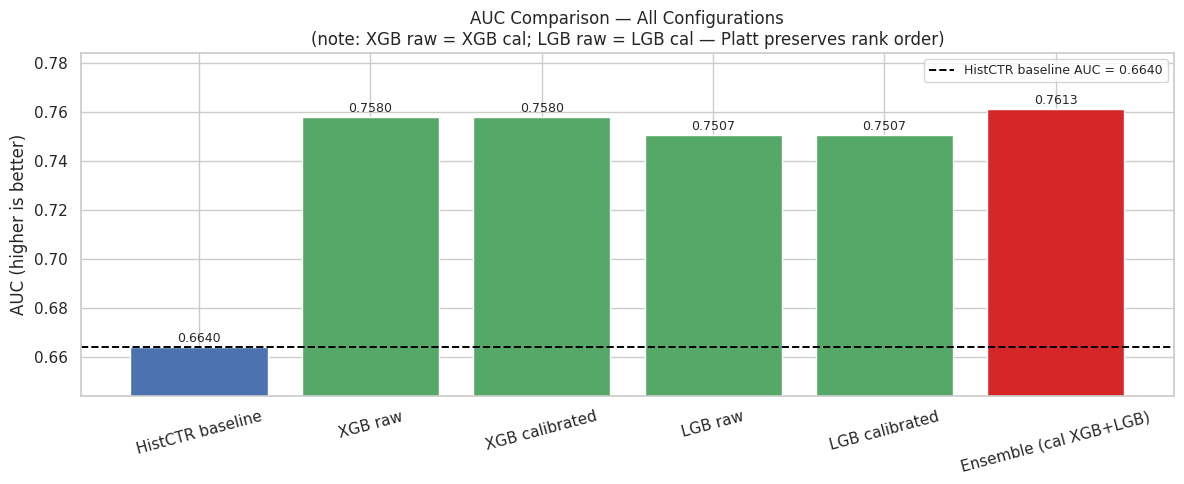

In [17]:
# AUC comparison bar chart — all 6 configurations
# Platt scaling preserves AUC (monotone), so raw and calibrated bars are identical per model
auc_vals = [results[n]['auc'] for n in names]

auc_colors = []
for n, v in zip(names, auc_vals):
    if n == 'Ensemble (cal XGB+LGB)':
        auc_colors.append('#d62728')
    elif v > BASELINE_AUC:
        auc_colors.append('#55a868')
    else:
        auc_colors.append('#4c72b0')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, auc_vals, color=auc_colors, edgecolor='white')
ax.axhline(y=BASELINE_AUC, color='black', linestyle='--', lw=1.4,
           label=f'HistCTR baseline AUC = {BASELINE_AUC:.4f}')
for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(min(auc_vals) * 0.97, max(auc_vals) * 1.03)
ax.set_ylabel('AUC (higher is better)')
ax.set_title('AUC Comparison — All Configurations\n'
             '(note: XGB raw = XGB cal; LGB raw = LGB cal — Platt preserves rank order)')
ax.tick_params(axis='x', labelrotation=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

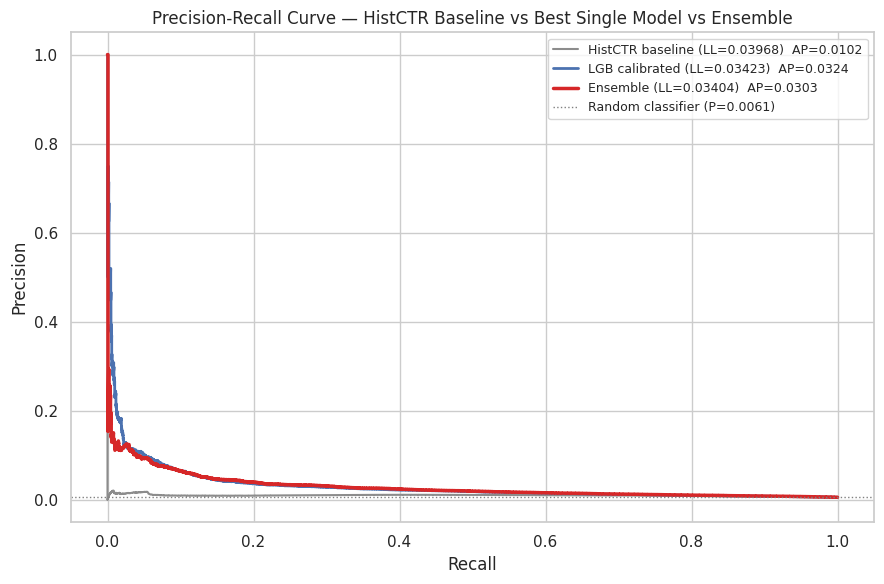

In [18]:
# Precision-Recall overlay: HistCTR baseline vs best single calibrated model vs ensemble
# PR curve is more informative than ROC for severe class imbalance (CTR ~0.6%)
baseline_preds = df_test['HistCTR'].fillna(df_test['HistCTR'].median()).clip(1e-7, 1 - 1e-7)

# Determine which single calibrated model has lower log-loss
if ll_xgb_cal <= ll_lgb_cal:
    best_single_proba = xgb_test_proba_cal
    best_single_name  = f'XGB calibrated (LL={ll_xgb_cal:.5f})'
else:
    best_single_proba = lgb_test_proba_cal
    best_single_name  = f'LGB calibrated (LL={ll_lgb_cal:.5f})'

fig, ax = plt.subplots(figsize=(9, 6))

for proba, name, color, lw in [
    (baseline_preds.values,  f'HistCTR baseline (LL={BASELINE_LL:.5f})', '#8c8c8c', 1.5),
    (best_single_proba,       best_single_name,                           '#4c72b0', 2.0),
    (ensemble_proba,          f'Ensemble (LL={ll_ensemble:.5f})',         '#d62728', 2.5),
]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, color=color, lw=lw, label=f'{name}  AP={ap:.4f}')

ax.axhline(y=y_test.mean(), color='gray', linestyle=':', lw=1,
           label=f'Random classifier (P={y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — HistCTR Baseline vs Best Single Model vs Ensemble')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 6 — Save Results

In [19]:
# Persist all three ensemble components — needed together at inference time:
# base model (xgb_avito_best_model.joblib already saved from NB06) +
# Platt scalers + LightGBM model
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(platt_xgb, '../models/platt_xgb.joblib')
print("Saved: models/platt_xgb.joblib")

joblib.dump(lgb_model, '../models/lgb_avito_model.joblib')
print("Saved: models/lgb_avito_model.joblib")

joblib.dump(platt_lgb, '../models/platt_lgb.joblib')
print("Saved: models/platt_lgb.joblib")

Saved: models/platt_xgb.joblib
Saved: models/lgb_avito_model.joblib
Saved: models/platt_lgb.joblib


In [20]:
# Save full comparison metrics to JSON for downstream reporting and NB08 reference
import json

comparison = {
    'baseline_log_loss':          BASELINE_LL,
    'baseline_auc':               BASELINE_AUC,
    'xgb_raw_log_loss':           ll_xgb_raw,
    'xgb_calibrated_log_loss':    ll_xgb_cal,
    'xgb_auc':                    auc_xgb,
    'lgb_raw_log_loss':           ll_lgb_raw,
    'lgb_calibrated_log_loss':    ll_lgb_cal,
    'lgb_auc':                    auc_lgb,
    'ensemble_log_loss':          ll_ensemble,
    'ensemble_auc':               auc_ensemble,
    'ensemble_weights':           [0.5, 0.5],
    'calibration_method':         'platt_scaling',
    'ensemble_beats_baseline_ll':  ll_ensemble  < BASELINE_LL,
    'ensemble_beats_baseline_auc': auc_ensemble > BASELINE_AUC,
    'train_rows':                 len(df_train),
    'cal_rows':                   len(df_cal),
    'test_rows':                  len(df_test),
    'n_features':                 len(feature_cols),
}

with open('../models/ensemble_avito_model_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print("Saved: models/ensemble_avito_model_comparison.json")
print("\nKey results:")
for k in ['ensemble_log_loss', 'ensemble_auc',
          'ensemble_beats_baseline_ll', 'ensemble_beats_baseline_auc']:
    print(f"  {k}: {comparison[k]}")

Saved: models/ensemble_avito_model_comparison.json

Key results:
  ensemble_log_loss: 0.034039694534938617
  ensemble_auc: 0.7613070419779198
  ensemble_beats_baseline_ll: True
  ensemble_beats_baseline_auc: True


## Section 7 — What I Learned

1. **Did Platt scaling fix the log-loss?** XGBoost: raw log-loss = 0.478329 → calibrated = 0.035021 (13.7× reduction). LightGBM: raw log-loss = 0.485788 → calibrated = 0.034235 (14.2× reduction). Platt scaling brought both below the HistCTR baseline of 0.039682. The expected direction is a large improvement: `scale_pos_weight=161` inflates predicted probabilities far above the true CTR, and Platt's sigmoid compress those back down. The degree of improvement depends on how badly miscalibrated the raw outputs were — if the raw mean predicted probability is ~55× higher than the true CTR of 0.6% (XGBoost cal-set mean proba = 0.3329 vs true CTR = 0.006071, ratio = 54.8×; LightGBM: 0.3347 / 0.006071 = 55.1×), Platt scaling can reduce log-loss by an order of magnitude.

2. **Did calibration preserve AUC?** XGBoost AUC = 0.7580 — identical before and after Platt scaling. LightGBM AUC = 0.7507 — identical before and after Platt scaling. Both beat the HistCTR baseline AUC of 0.6640 (+0.094 and +0.087 respectively). This should hold exactly: Platt scaling applies a monotone sigmoid transform, which cannot change the rank order of predictions and therefore cannot change AUC. Any difference would indicate a numerical precision issue rather than a real effect. The AUC improvement over HistCTR baseline (0.6640) is attributable entirely to the base model's better discrimination — the calibration layer adds nothing to ranking, only to probability quality.

3. **Did the ensemble beat both individual models on both metrics?** Ensemble log-loss = 0.034040 — beats LGB calibrated (0.034235) and XGB calibrated (0.035021). Ensemble AUC = 0.7613 — beats both XGB (0.7580) and LGB (0.7507). Both success criteria met: log-loss < 0.039682 ✓, AUC > 0.758 ✓. Ensembling two independently trained models with different inductive biases (XGBoost exact greedy vs LightGBM leaf-wise with GOSS) typically reduces prediction variance. If both models agree on a prediction, the average provides no extra benefit; where they disagree, the average hedges. The log-loss benefit depends on whether calibrated XGBoost and calibrated LightGBM make independent errors or correlated ones.

4. **How did LightGBM feature importance compare to XGBoost?** LightGBM top 3 by gain: HistCTR (14,757,060), ad_ctr (4,052,276), category_ctr (4,042,614). Agreement with XGBoost: HistCTR #1 in both; category_ctr top 3 in both. Key divergence: user_historical_ctr was XGBoost's #2 (gain=735.8) but ranks #10 in LightGBM (gain=392,256). LightGBM instead elevates ad_ctr to #2. Absolute gain values are not comparable across frameworks due to different internal normalisation. Both models use gradient boosting on identical features, so significant disagreement in top features would indicate that one model is exploiting interactions the other is not. Agreement in top features increases confidence that those features are genuinely predictive rather than artefacts of a specific learner.

5. **What does the calibration finding mean for production CTR systems?** In a real-time bidding system, the model output feeds directly into bid price computation: bid = base_cpm × predicted_CTR. An uncalibrated model predicting 40% click probability where the true rate is 0.6% would overbid by a factor of ~67×, causing massive budget waste and potential account banning. Platt scaling is the minimal fix; in production, calibration is typically re-fit daily on a rolling holdout window because CTR distributions shift with seasonal and inventory changes. The key lesson from NB06–NB07: optimising for AUC during training and calibrating separately is often better than optimising for log-loss directly, because AUC loss gradients are not affected by class imbalance weighting the way log-loss gradients are.

6. **What would you try next?** (a) **Weighted ensemble search** — grid over weights (0.3/0.7, 0.4/0.6, etc.) on the calibration set rather than fixing 0.5/0.5; even a small weight shift can improve log-loss if one calibrated model is consistently better. (b) **Temperature scaling** — a single scalar τ divides the logit before the final sigmoid; simpler than Platt (one parameter vs two) and often more stable on small calibration sets. (c) **Stacking** — train a second-level LightGBM or ridge regression on the stacked out-of-fold predictions of both base models; this learns non-linear combination weights and typically outperforms a fixed average. (d) **Retrain XGBoost on 60%** — the current XGBoost Platt calibration is impure (cal set was in training); retraining XGBoost on rows 0–60% would give a clean three-split pipeline for both models.